# KL-analysis

ref: http://joschu.net/blog/kl-approx.html

# 三种KL的均值和方差

标准的KL是：每个类别的概率都要做KL， 

1. 而logprob的形式是特定的类别做KL，即是下面代码k1（但是具体类别选logprob）

In [31]:

import torch.distributions as dis
p = dis.Normal(loc=0, scale=1)
q = dis.Normal(loc=0.5, scale=1)
x = q.sample(sample_shape=(100_000,))
truekl = dis.kl_divergence(p, q)
print("true", truekl)
logr = p.log_prob(x) - q.log_prob(x)
k1 = -logr # 这个版本是logprob版本
k2 = logr ** 2 / 2
k3 = (logr.exp() - 1) - logr

print('------')
print(truekl )

print('------')
print('KL的均值和标准差')
for i, k in enumerate((k1, k2, k3)):
    # 注意：相较原KL差异
    print(i+1, k.mean() , k.std())
    
print('------')
print('与标准KL比较')
for i, k in enumerate((k1, k2, k3)):
    # 注意：相较原KL差异
    print(i+1, (k.mean() - truekl) / truekl, k.std() / truekl)
 

true tensor(0.1250)

------

tensor(0.1250)

------

KL的均值和标准差

...

------

与标准KL比较

1 tensor(-0.0110) tensor(4.0012)

2 tensor(0.0617) tensor(1.4950)

3 tensor(0.0014) tensor(1.4727)

In [13]:
# K2 和 K3 的 KL 值都是正值， K1有负值
print(len(x))
print(k1[:10])
print(k2[:10])
print(k3[:10])

10000000

tensor([ 0.2883,  0.2140,  0.6077,  0.3448,  1.1041, -0.4864, -0.1960,  0.7993,
         0.2015,  0.1195])

tensor([0.0416, 0.0229, 0.1846, 0.0594, 0.6095, 0.1183, 0.0192, 0.3194, 0.0203,
        0.0071])

tensor([0.0378, 0.0213, 0.1523, 0.0531, 0.4356, 0.1400, 0.0205, 0.2489, 0.0190,
        0.0069])

# K1 散点分布

1. 均值为0，即在y轴对称
2. 由于有负值，所以方差大

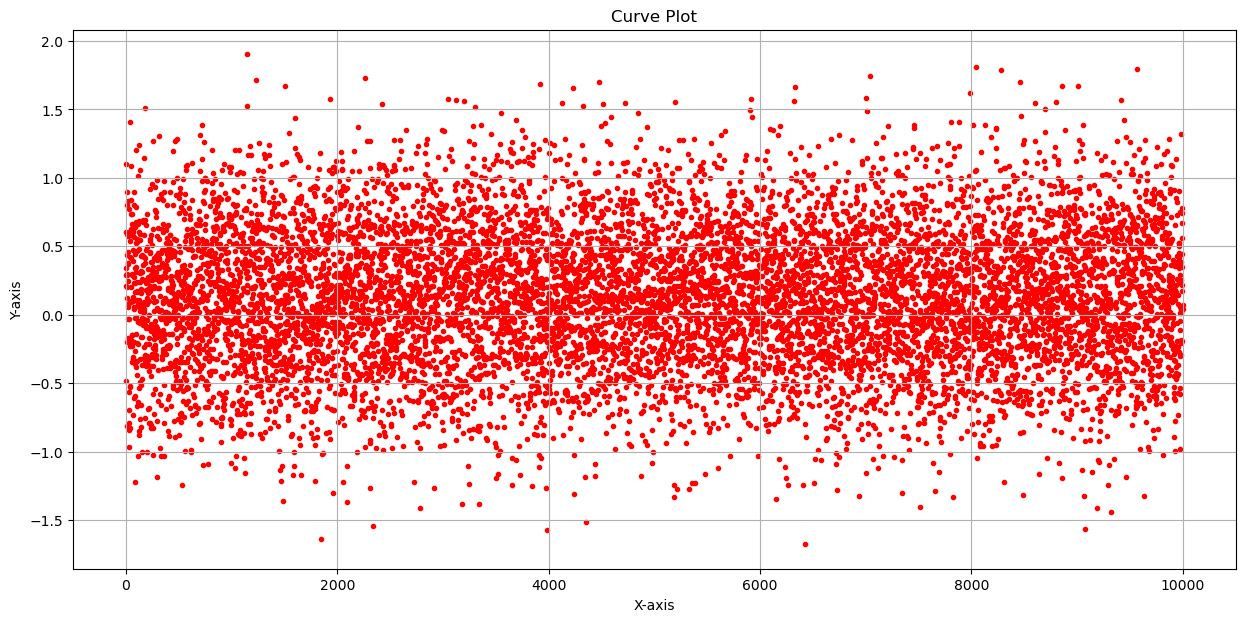

In [14]:
import torch
import matplotlib.pyplot as plt

sample_num = 10000

# 绘制曲线图
plt.figure(figsize=(15, 7))
plt.scatter(range(sample_num), k1[:sample_num].tolist(), color='red', marker='.')  # 使用 marker='o' 来显示数据点
plt.title('Curve Plot')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.grid()
plt.show()

# K2,K3 散点图

下图明显K3的K2, 都是正值

In [16]:
# k3均值更小。
print(k2.mean())
print(k3.mean())

tensor(0.1329)

tensor(0.1251)

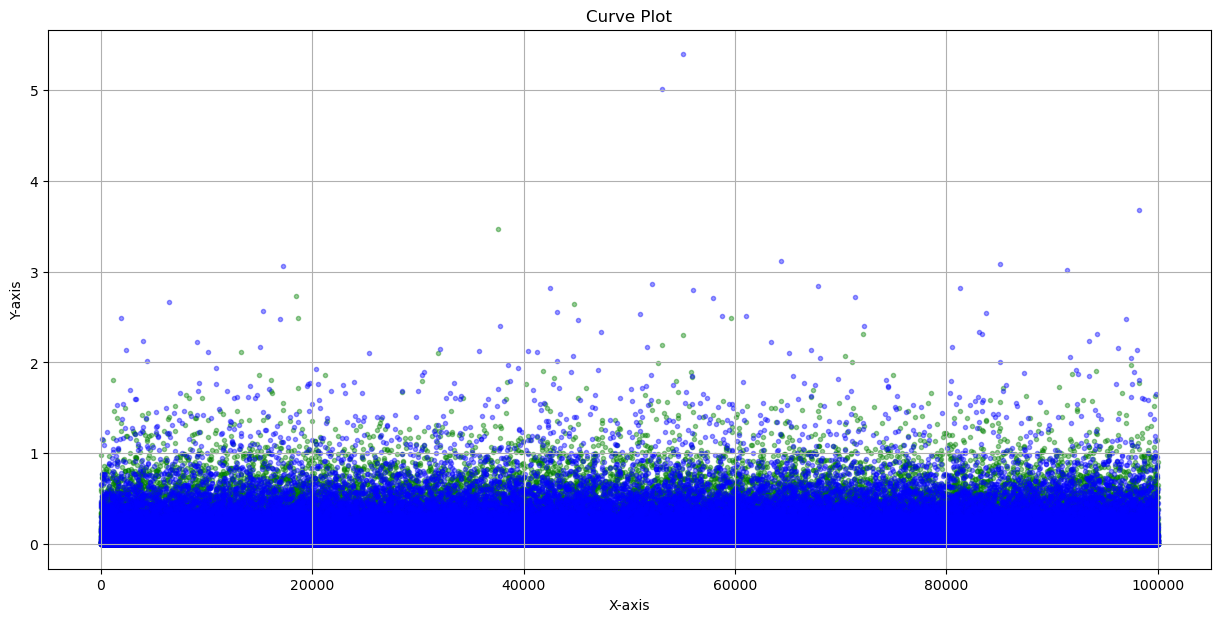

In [17]:
import torch
import matplotlib.pyplot as plt

# # 示例数据

sample_num = 100000

# 绘制曲线图
plt.figure(figsize=(15, 7))
plt.scatter(range(sample_num), k2[:sample_num].tolist(), color='green', marker='.', alpha=0.4)  # 使用 marker='o' 来显示数据点
plt.scatter(range(sample_num), k3[:sample_num].tolist(), color='blue', marker='.', alpha=0.4)  # 使用 marker='o' 来显示数据点
plt.title('Curve Plot')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.grid()
plt.show()

# 不同KL随 qx/px 变化

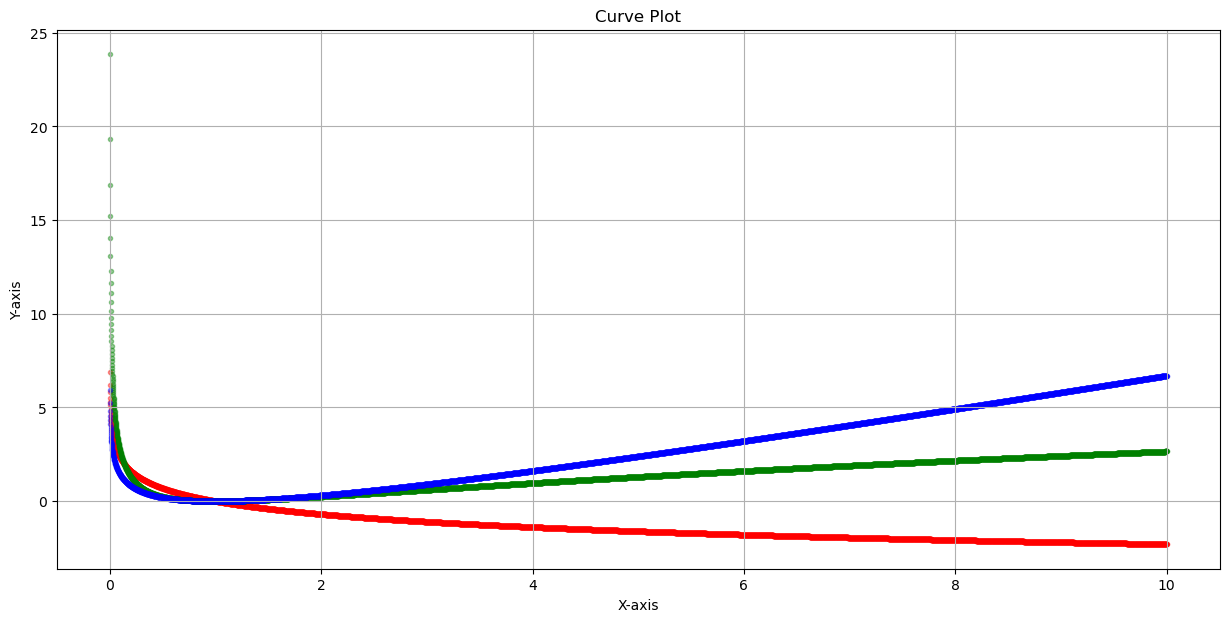

In [54]:
import torch
import matplotlib.pyplot as plt


x = torch.arange(0, 10.001, 0.001)
y1 = -x.log()
y2 = x.log()**2 / 2
y3 = x-1 - x.log()


# 绘制曲线图
plt.figure(figsize=(15, 7))
plt.scatter(x.tolist(), y1.tolist(), color='red', marker='.', alpha=0.4)  # 使用 marker='o' 来显示数据点
plt.scatter(x.tolist(), y2.tolist(), color='green', marker='.', alpha=0.4)  # 使用 marker='o' 来显示数据点
plt.scatter(x.tolist(), y3.tolist(), color='blue', marker='.', alpha=0.4)  # 使用 marker='o' 来显示数据点
plt.title('Curve Plot')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.grid()
plt.show()

# K3 (x-1) > x.log() 图像

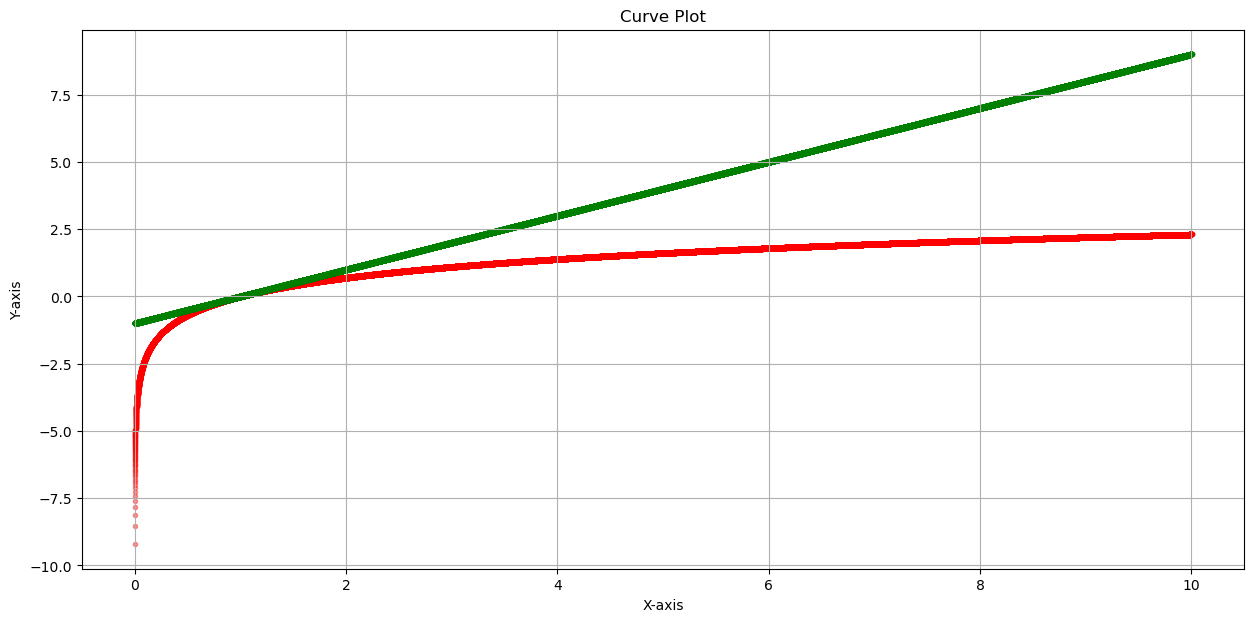

In [58]:
import torch
import matplotlib.pyplot as plt


x = torch.arange(0, 10.001, 0.0001)
y1 = x.log()
y2 = x - 1


# 绘制曲线图
plt.figure(figsize=(15, 7))
plt.scatter(x.tolist(), y1.tolist(), color='red', marker='.', alpha=0.4)  # 使用 marker='o' 来显示数据点
plt.scatter(x.tolist(), y2.tolist(), color='green', marker='.', alpha=0.4)  # 使用 marker='o' 来显示数据点
plt.title('Curve Plot')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.grid()
plt.show()